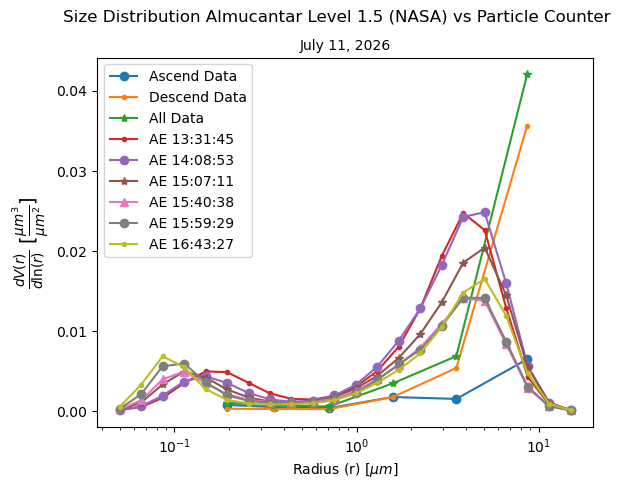

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# NASA Aeronet Data:
data = pd.read_csv('20260711_Rexburg_Idaho.csv')

y1 = data.iloc[0,5:27].values
y2 = data.iloc[1,5:27].values
y3 = data.iloc[2,5:27].values
y4 = data.iloc[3,5:27].values
y5 = data.iloc[4,5:27].values
y6 = data.iloc[5,5:27].values

x = data.columns[5:27].astype(float).values

# Particle Counter (PC) Calculation:
particle = pd.read_csv('Particle_Counter_Data_July_11_2026_Flight.csv')
alt = pd.read_csv('AltitudeData07.11(KO6DQM).csv')

particle['Time'] = pd.to_datetime(particle['Time'], errors='coerce').dt.floor('min')
alt['Time'] = pd.to_datetime(alt['time'], errors='coerce').dt.floor('min')

start_time = pd.Timestamp('2026-07-11 15:49:00')
end_time = pd.Timestamp('2026-07-11 17:26:00')

particle_strip = particle[(particle['Time']>=start_time) & (particle['Time']<=end_time)]

data = pd.merge(particle_strip,alt, on=['Time'], how='left')
df = data[['Time','Size1','Count1 (dM3)','Size2','Count2 (dM3)',
          'Size3','Count3 (dM3)','Size4','Count4 (dM3)','Size5',
          'Count5 (dM3)','Size6','Count6 (dM3)','altitude']].copy()

df['altitude_raw'] = pd.to_numeric(df['altitude'], errors='coerce')
df['altitude'] = df['altitude'].interpolate(method='linear',limit_area='inside')

count_cols = ['Count1 (dM3)','Count2 (dM3)','Count3 (dM3)',
                  'Count4 (dM3)','Count5 (dM3)','Count6 (dM3)']

D_edges = np.array([df['Size1'][0],df['Size2'][0],df['Size3'][0],
                    df['Size4'][0],df['Size5'][0],df['Size6'][0],30],dtype=float)
r_edges = D_edges/2

r_mid = np.sqrt(r_edges[:-1]*r_edges[1:])
dlnr = np.log(r_edges[1:]/r_edges[:-1])

dN_dM3 = df[count_cols].to_numpy(dtype=float)
dVdlnr_local = (4*np.pi/3)*(r_mid**3)*(dN_dM3/dlnr)

dN_dM3 = df[count_cols].to_numpy(dtype=float)
dVdlnr_local = (4*np.pi/3)*(r_mid**3)*(dN_dM3/dlnr)

for i,r in enumerate(r_mid):
    df[f'dVdlnr{i+1}'] = dVdlnr_local[:,i]

idx_max_alt = df['altitude'].idxmax()
df_ascent = df.loc[:idx_max_alt].copy()
df_descent = df.loc[idx_max_alt:].copy()

# Calculating Ascending Data
z = np.array(df_ascent['altitude'])
dz = np.abs(np.diff(z)) # calculate Δz
dVdlnr1 = np.array(df_ascent['dVdlnr1'])
dVdlnr2 = np.array(df_ascent['dVdlnr2'])
dVdlnr3 = np.array(df_ascent['dVdlnr3'])
dVdlnr4 = np.array(df_ascent['dVdlnr4'])
dVdlnr5 = np.array(df_ascent['dVdlnr5'])
dVdlnr6 = np.array(df_ascent['dVdlnr6'])

# Left Riemann Sum and Convert to um^2
p1 = sum(dVdlnr1[:-1]*dz)*(1e-6)**2
p2 = sum(dVdlnr2[:-1]*dz)*(1e-6)**2
p3 = sum(dVdlnr3[:-1]*dz)*(1e-6)**2
p4 = sum(dVdlnr4[:-1]*dz)*(1e-6)**2
p5 = sum(dVdlnr5[:-1]*dz)*(1e-6)**2
p6 = sum(dVdlnr6[:-1]*dz)*(1e-6)**2

py = np.array([p1,p2,p3,p4,p5,p6],dtype=float)

# Calculating Descending Data
zd = np.array(df_descent['altitude'])
dzd = np.abs(np.diff(zd)) # calculate Δz
dVdlnr1d = np.array(df_descent['dVdlnr1'])
dVdlnr2d = np.array(df_descent['dVdlnr2'])
dVdlnr3d = np.array(df_descent['dVdlnr3'])
dVdlnr4d = np.array(df_descent['dVdlnr4'])
dVdlnr5d = np.array(df_descent['dVdlnr5'])
dVdlnr6d = np.array(df_descent['dVdlnr6'])

# Left Riemann Sum and Convert to um^2
p1d = sum(dVdlnr1d[:-1]*dzd)*(1e-6)**2
p2d = sum(dVdlnr2d[:-1]*dzd)*(1e-6)**2
p3d = sum(dVdlnr3d[:-1]*dzd)*(1e-6)**2
p4d = sum(dVdlnr4d[:-1]*dzd)*(1e-6)**2
p5d = sum(dVdlnr5d[:-1]*dzd)*(1e-6)**2
p6d = sum(dVdlnr6d[:-1]*dzd)*(1e-6)**2

pyd = np.array([p1d,p2d,p3d,p4d,p5d,p6d],dtype=float)

# Calculating Round Trip
zr = np.array(df['altitude'])
dzr = np.abs(np.diff(zr)) # calculate Δz
dVdlnr1r = np.array(df['dVdlnr1'])
dVdlnr2r = np.array(df['dVdlnr2'])
dVdlnr3r = np.array(df['dVdlnr3'])
dVdlnr4r = np.array(df['dVdlnr4'])
dVdlnr5r = np.array(df['dVdlnr5'])
dVdlnr6r = np.array(df['dVdlnr6'])

# Left Riemann Sum and Convert to um^2
p1r = sum(dVdlnr1r[:-1]*dzr)*(1e-6)**2
p2r = sum(dVdlnr2r[:-1]*dzr)*(1e-6)**2
p3r = sum(dVdlnr3r[:-1]*dzr)*(1e-6)**2
p4r = sum(dVdlnr4r[:-1]*dzr)*(1e-6)**2
p5r = sum(dVdlnr5r[:-1]*dzr)*(1e-6)**2
p6r = sum(dVdlnr6r[:-1]*dzr)*(1e-6)**2

pyr = np.array([p1r,p2r,p3r,p4r,p5r,p6r],dtype=float)

plt.plot(r_mid,py,'o-',label='Ascend Data')
plt.plot(r_mid,pyd,'.-',label='Descend Data')
plt.plot(r_mid,pyr,'*-',label='All Data')
plt.plot(x, y1, '.-', label="AE 13:31:45")
plt.plot(x, y2, 'o-', label="AE 14:08:53")
plt.plot(x, y3, '*-', label="AE 15:07:11")
plt.plot(x, y4, '^-', label="AE 15:40:38")
plt.plot(x, y5, 'o-', label="AE 15:59:29")
plt.plot(x, y6, '.-', label="AE 16:43:27")     
plt.xscale('log')
plt.ylabel(r'$\frac{dV(r)}{d\ln(r)}$ [$\frac{\mu m^3}{\mu m^2}$]', fontsize=14)
plt.xlabel(r'Radius (r) [$\mu m$]')
plt.suptitle('Size Distribution Almucantar Level 1.5 (NASA) vs Particle Counter')
plt.title("July 11, 2026", fontsize=10)
plt.legend()
plt.show()